In [24]:
from pathlib import Path
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pathlib
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import torch.optim as optim
import time
import sys
#sys.path.append("/Users/deborahfu/eecs281/eecs545/Project/neurovfm")

#print(os.path.exists("/Users/deborahfu/eecs281/eecs545/Project/neurovfm"))

from mil import pad_ragged, AggregateThenClassify, ClassifyThenAggregate
     


In [25]:
folder_path = '/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings'
sum_ = 0.0
sq_sum = 0.0
count = 0
for f in os.listdir(folder_path):
    if f.endswith(".pt"):
        x = torch.load(os.path.join(folder_path, f)).float()
        sum_ += x.sum().item()
        sq_sum += (x**2).sum().item()
        count += x.numel()
mean = sum_ / count
std = ((sq_sum / count) - mean ** 2) ** 0.5
print("mean:", mean)
print("std:", std)

mean: -0.0034557271977380373
std: 0.058579403639728564


In [26]:
path_openbhb = pathlib.Path(folder_path)
adni_folder_path = '/Users/racheliritani/Desktop/neurovfm/output/ADNI_train_embeddings'
path_adni = pathlib.Path(adni_folder_path)

# Load both metadata files
subject_meta = pd.read_csv('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/for_training_participants.tsv', sep='\t')
subject_meta['participant_id'] = subject_meta['participant_id'].astype(str)

adni_meta_path = os.path.join(adni_folder_path, '00_adni_metadata.tsv')
adni_meta = pd.read_csv(adni_meta_path, sep='\t')
# Extract participant_id from source_file column (assuming it contains filenames like '002_S_0413_encoder_embeddings.pt')
adni_meta['participant_id'] = adni_meta['source_file'].str.extract(r'(.+)_encoder_embeddings\.pt')
adni_meta['participant_id'] = adni_meta['participant_id'].astype(str)

# Patterns for each dataset
openbhb_pattern = re.compile(r'sub-([^_]+)_encoder_embeddings\.pt')
adni_pattern = re.compile(r'(.+)_encoder_embeddings\.pt')

# Separate lists for each dataset
openbhb_data_list = []
adni_data_list = []

# Load from OpenBHB folder
for file in path_openbhb.glob('*.pt'):
    if openbhb_pattern.match(file.name):
        match = openbhb_pattern.search(file.name)
        subj_id = match.group(1)
        emb_tensor = torch.load(file, map_location='cpu')
        openbhb_data_list.append({
            'subject id': subj_id,
            'embedding': emb_tensor.detach().cpu()
        })

# Load from ADNI folder
for file in path_adni.glob('*.pt'):
    if adni_pattern.match(file.name):
        match = adni_pattern.search(file.name)
        subj_id = match.group(1)
        emb_tensor = torch.load(file, map_location='cpu')
        adni_data_list.append({
            'subject id': subj_id,
            'embedding': emb_tensor.detach().cpu()
        })

# Create DataFrames
openbhb_emb_df = pd.DataFrame(openbhb_data_list)
adni_emb_df = pd.DataFrame(adni_data_list)

# Merge with metadata
openbhb_age_embedding_df = pd.merge(openbhb_emb_df, subject_meta, left_on='subject id', right_on='participant_id', how='inner')
adni_age_embedding_df = pd.merge(adni_emb_df, adni_meta, left_on='subject id', right_on='participant_id', how='inner')

# Combine datasets
combined_df = pd.concat([openbhb_age_embedding_df, adni_age_embedding_df], ignore_index=True)

train_df, eval_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [27]:
import numpy as np

# Define dataset and collate function
class BagDataset(Dataset):
    def __init__(self, df):
        self.embeddings = list(df['embedding'])
        self.ages = torch.tensor(df['age'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ages)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.ages[idx]

def collate_bags(batch):
    emb_list, ages = zip(*batch)
    lengths = [x.shape[0] for x in emb_list]
    cu_seqlens = torch.tensor([0] + np.cumsum(lengths).tolist(), dtype=torch.long)
    emb_cat = torch.cat(emb_list, dim=0)
    ages = torch.stack(ages)
    return emb_cat, cu_seqlens, ages

# Create datasets
train_dataset = BagDataset(train_df)
eval_dataset = BagDataset(eval_df)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_bags,
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_bags,
)

In [28]:
class ABMILRegression(nn.Module):
    def __init__(self, dim, hidden_dim=None):
        super().__init__()
        self.pooling = AggregateThenClassify(dim=dim, hidden_dim = hidden_dim, W_out=1)
        self.regression = nn.Linear(dim,1)
    def forward(self, emb_list, seq_position, return_attn_weights=False):
        bags, attn_weights = self.pooling(emb_list, seq_position, return_attn_probs=True)
        output = self.regression(bags).squeeze(-1)
        
        if return_attn_weights:
            return output, attn_weights
        else:
            return output

In [29]:
#cell for inspecting embeddings, sanity check
data1 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/sub-100053248969_encoder_embeddings.pt')
data2 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/sub-100263562592_encoder_embeddings.pt')
data3 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/sub-102730278561_encoder_embeddings.pt')
data4 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/sub-103116472269_encoder_embeddings.pt')
data5 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/sub-104756934188_encoder_embeddings.pt')
print(data1.shape)
print(data2.shape)
print(data3.shape)
print(data4.shape)
print(data5.shape)

torch.Size([778, 768])
torch.Size([783, 768])
torch.Size([784, 768])
torch.Size([764, 768])
torch.Size([791, 768])


In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ABMILRegression(dim = 768, hidden_dim = 256).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Model initialize on {device}')

Model initialize on cpu


In [31]:
def train_epoch(model, data_loader, optimizer, criterion, device, epochs=100, return_attn_weights=False):
    train_losses = []
    eval_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for emb_cat, cu_seqlens, ages in train_loader:
            emb_cat = emb_cat.to(device, dtype=torch.float32)
            cu_seqlens = cu_seqlens.to(device, dtype=torch.long)
            ages = ages.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            outputs = model(emb_cat, cu_seqlens)
            loss = criterion(outputs, ages)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        eval_loss = 0.0
        all_ages = []
        all_outputs = []
        all_attn_weights = [] if return_attn_weights else None
        all_cu_seqlens = [] if return_attn_weights else None  # Track sequence lengths for splitting

        with torch.no_grad():
            for emb_cat, cu_seqlens, ages in eval_loader:
                emb_cat = emb_cat.to(device, dtype=torch.float32)
                cu_seqlens = cu_seqlens.to(device, dtype=torch.long)
                ages = ages.to(device, dtype=torch.float32)

                if return_attn_weights:
                    outputs, attn_weights = model(emb_cat, cu_seqlens, return_attn_weights=True)
                    all_attn_weights.append(attn_weights.cpu())
                    all_cu_seqlens.append(cu_seqlens.cpu())  # Store for later splitting
                else:
                    outputs = model(emb_cat, cu_seqlens)

                loss = criterion(outputs, ages)
                eval_loss += loss.item()

                all_ages.append(ages.cpu())
                all_outputs.append(outputs.cpu())

        eval_loss = eval_loss / len(eval_loader)
        eval_losses.append(eval_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {eval_loss:.4f}")

    all_ages = torch.cat(all_ages)
    all_outputs = torch.cat(all_outputs)

    # Process attention weights to create per-subject maps
    if return_attn_weights:
        all_attn_weights = torch.cat(all_attn_weights)  # [total_tokens, 1]

        # Create per-subject attention weight maps
        subject_attention_maps = []
        token_offset = 0

        for batch_cu_seqlens in all_cu_seqlens:
            # batch_cu_seqlens includes the starting 0, so we iterate through pairs
            for i in range(len(batch_cu_seqlens) - 1):
                start_idx = batch_cu_seqlens[i].item()
                end_idx = batch_cu_seqlens[i + 1].item()
                seq_length = end_idx - start_idx

                # Extract attention weights for this subject
                subject_attn = all_attn_weights[token_offset + start_idx:token_offset + end_idx]
                subject_attention_maps.append(subject_attn.squeeze(-1))  # Remove last dim

            token_offset += batch_cu_seqlens[-1].item()

        all_attn_weights = subject_attention_maps  # Now a list of tensors, one per subject

    return train_losses, eval_losses, all_ages, all_outputs, all_attn_weights

In [32]:
start_time = time.time()
train_losses, val_losses, age, outputs, attn_weights = train_epoch(model, train_loader, optimizer, criterion, device, epochs=100, return_attn_weights=True)
end_time = time.time()
total_time = end_time - start_time
print(f"Training Complete!")
print(f"Total time: {int(total_time // 60)}m {int(total_time % 60)}s")

Epoch [10/100] | Train Loss: 149.2545 | Val Loss: 246.2676
Epoch [20/100] | Train Loss: 38.5796 | Val Loss: 59.9878
Epoch [30/100] | Train Loss: 38.0520 | Val Loss: 43.7063
Epoch [40/100] | Train Loss: 35.7226 | Val Loss: 53.1860
Epoch [50/100] | Train Loss: 35.2147 | Val Loss: 53.4254
Epoch [60/100] | Train Loss: 34.1255 | Val Loss: 52.1192
Epoch [70/100] | Train Loss: 31.2278 | Val Loss: 49.3554
Epoch [80/100] | Train Loss: 25.7004 | Val Loss: 40.9669
Epoch [90/100] | Train Loss: 20.0408 | Val Loss: 35.7989
Epoch [100/100] | Train Loss: 11.1082 | Val Loss: 41.7534
Training Complete!
Total time: 0m 9s


MODEL EVALUATION METRICS
Mean Absolute Error (MAE):  5.9993 years
Mean Squared Error (MSE):   41.7534
Root Mean Squared Error (RMSE): 6.4617 years
R² Score:                   -0.3803
Correlation Coefficient:    -1.0000

ATTENTION WEIGHTS ANALYSIS
Attention weights shape: torch.Size([1575])
Attention weights range: [0.0000, 0.8598]
Attention weights mean: 0.0013
Attention weights std: 0.0294


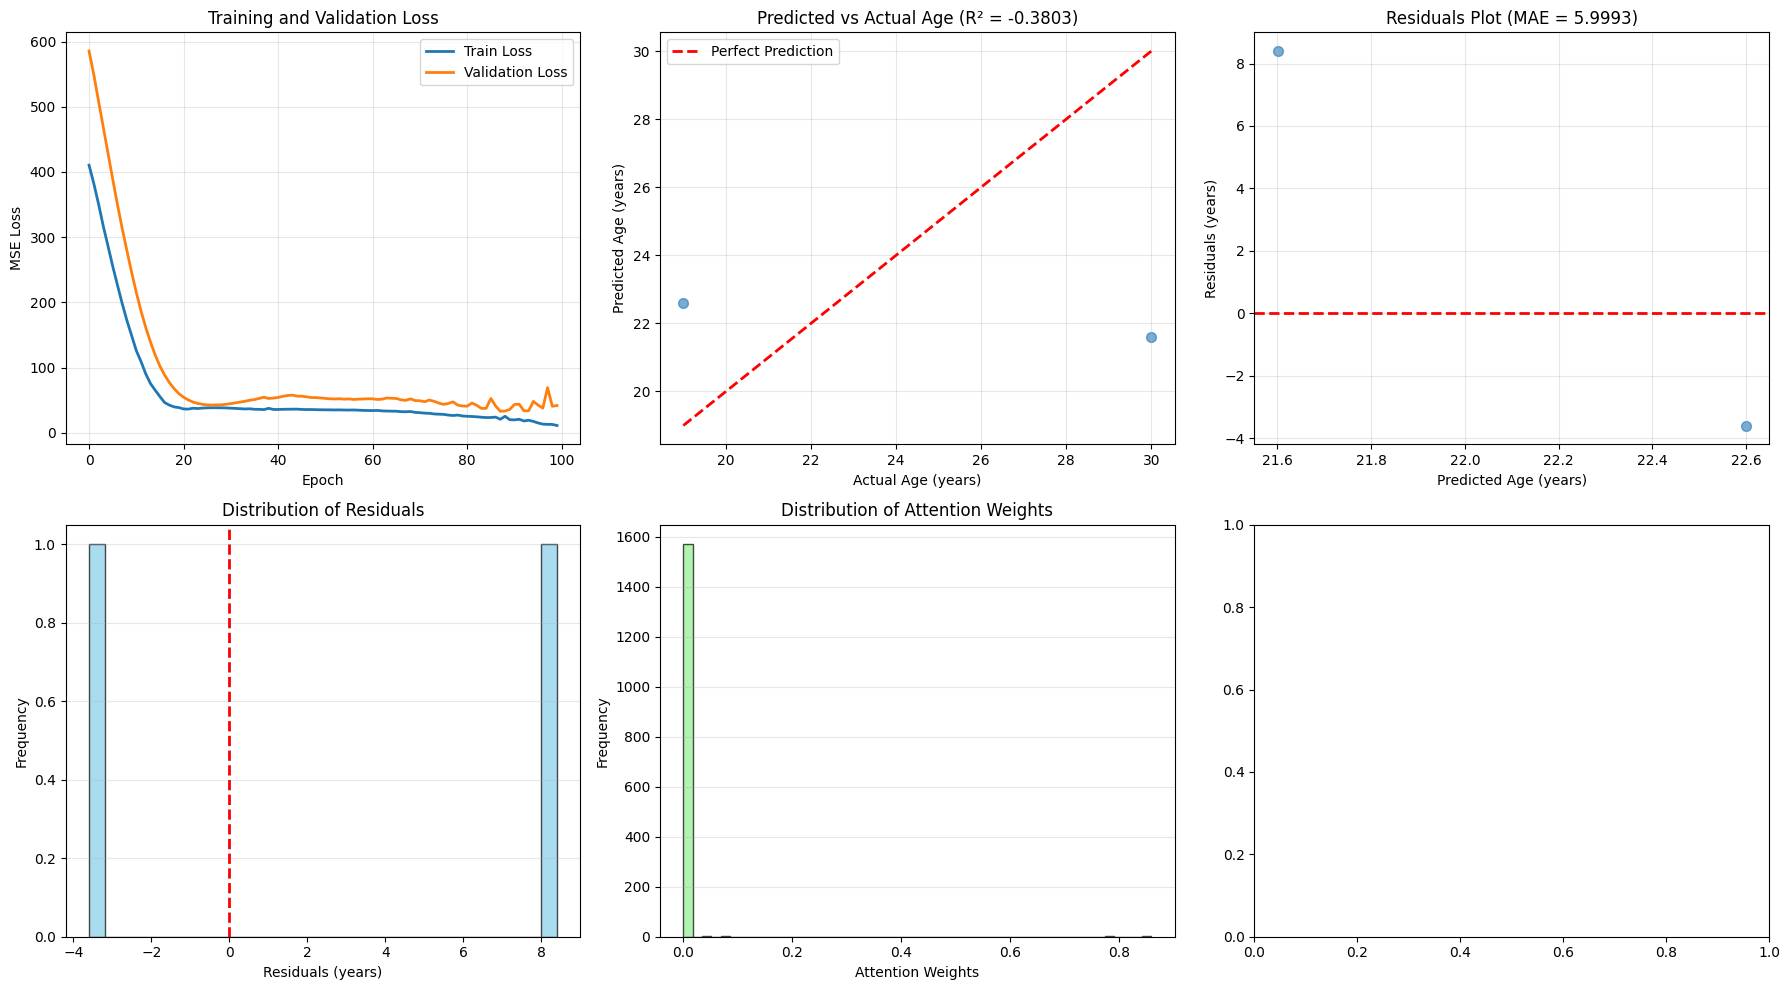

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute regression metrics
mae = mean_absolute_error(age.numpy(), outputs.numpy())
mse = mean_squared_error(age.numpy(), outputs.numpy())
rmse = np.sqrt(mse)
r2 = r2_score(age.numpy(), outputs.numpy())
correlation = np.corrcoef(age.numpy(), outputs.numpy())[0, 1]

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Mean Absolute Error (MAE):  {mae:.4f} years")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} years")
print(f"R² Score:                   {r2:.4f}")
print(f"Correlation Coefficient:    {correlation:.4f}")
print("=" * 50)

# Attention weights analysis
if attn_weights is not None:
    all_attn = torch.cat(attn_weights)
    print("\nATTENTION WEIGHTS ANALYSIS")
    print("=" * 50)
    print(f"Attention weights shape: {all_attn.shape}")
    print(f"Attention weights range: [{all_attn.min().item():.4f}, {all_attn.max().item():.4f}]")
    print(f"Attention weights mean: {all_attn.mean().item():.4f}")
    print(f"Attention weights std: {all_attn.std().item():.4f}")
    print("=" * 50)

# Create figure with subplots - expand to 2x3 grid to show both distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training and validation loss curves
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Predicted vs Actual scatter plot
axes[0, 1].scatter(age.numpy(), outputs.numpy(), alpha=0.6, s=50)
min_val = min(age.min(), outputs.min())
max_val = max(age.max(), outputs.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Age (years)')
axes[0, 1].set_ylabel('Predicted Age (years)')
axes[0, 1].set_title(f'Predicted vs Actual Age (R² = {r2:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals plot
residuals = age.numpy() - outputs.numpy()
axes[0, 2].scatter(outputs.numpy(), residuals, alpha=0.6, s=50)
axes[0, 2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Predicted Age (years)')
axes[0, 2].set_ylabel('Residuals (years)')
axes[0, 2].set_title(f'Residuals Plot (MAE = {mae:.4f})')
axes[0, 2].grid(True, alpha=0.3)

# 4. Residuals distribution
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals (years)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Attention weights distribution (if available)
if attn_weights is not None:
    all_attn = torch.cat(attn_weights).numpy()
    axes[1, 1].hist(all_attn, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1, 1].set_xlabel('Attention Weights')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Attention Weights')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 1].text(0.5, 0.5, 'No Attention Weights\nAvailable', 
                    ha='center', va='center', transform=axes[1, 1].transAxes,
                    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    axes[1, 1].set_title('Attention Weights Distribution')
    axes[1, 1].set_xlabel('Attention Weights')
    axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [34]:
import os
from datetime import datetime

# Create timestamped output directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"/Users/racheliritani/Desktop/neurovfm/abmil_results_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"Saving results to: {output_dir}")

# 1. Save the evaluation figure
fig_path = os.path.join(output_dir, "evaluation_metrics.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Figure saved: {fig_path}")

# 2. Save metrics to text file
metrics_path = os.path.join(output_dir, "metrics_summary.txt")
with open(metrics_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("ABMIL REGRESSION MODEL - EVALUATION METRICS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("DATASET INFORMATION:\n")
    f.write(f"  Train set size: {len(train_df)}\n")
    f.write(f"  Eval set size: {len(eval_df)}\n")
    f.write(f"  Total samples: {len(combined_df)}\n")
    f.write(f"  Train-Eval split: 80-20\n\n")
    
    f.write("MODEL CONFIGURATION:\n")
    f.write(f"  Input dimension: 768\n")
    f.write(f"  Hidden dimension: 256\n")
    f.write(f"  Pooling method: AggregateThenClassify\n")
    f.write(f"  Batch size: 4\n")
    f.write(f"  Epochs: 100\n")
    f.write(f"  Learning rate: 0.001\n")
    f.write(f"  Optimizer: Adam\n")
    f.write(f"  Loss function: MSE\n\n")
    
    f.write("EVALUATION METRICS:\n")
    f.write(f"  Mean Absolute Error (MAE):     {mae:.4f} years\n")
    f.write(f"  Mean Squared Error (MSE):      {mse:.4f}\n")
    f.write(f"  Root Mean Squared Error (RMSE): {rmse:.4f} years\n")
    f.write(f"  R² Score:                      {r2:.4f}\n")
    f.write(f"  Correlation Coefficient:       {correlation:.4f}\n\n")
    
    if attn_weights is not None:
        overall_attn = torch.cat(attn_weights)
        f.write("ATTENTION WEIGHTS STATISTICS:\n")
        f.write(f"  Attention weights shape: {overall_attn.shape}\n")
        f.write(f"  Attention weights range: [{overall_attn.min().item():.4f}, {overall_attn.max().item():.4f}]\n")
        f.write(f"  Attention weights mean: {overall_attn.mean().item():.4f}\n")
        f.write(f"  Attention weights std: {overall_attn.std().item():.4f}\n\n")
    
    f.write("LOSS CURVES:\n")
    f.write(f"  Final training loss:   {train_losses[-1]:.4f}\n")
    f.write(f"  Final validation loss: {val_losses[-1]:.4f}\n")
    f.write("=" * 60 + "\n")

print(f"✓ Metrics saved: {metrics_path}")

# 3. Save detailed predictions to CSV
predictions_path = os.path.join(output_dir, "predictions.csv")
predictions_df = pd.DataFrame({
    'actual_age': age.numpy(),
    'predicted_age': outputs.numpy(),
    'residual': (age.numpy() - outputs.numpy()),
    'absolute_error': np.abs(age.numpy() - outputs.numpy())
})
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Predictions saved: {predictions_path}")

# 4. Save attention weights to CSV (if available)
if attn_weights is not None:
    overall_attn = torch.cat(attn_weights)
    attn_weights_path = os.path.join(output_dir, "attention_weights.csv")
    attn_df = pd.DataFrame({
        'attention_weight': overall_attn.numpy()
    })
    attn_df.to_csv(attn_weights_path, index=False)
    print(f"✓ Attention weights saved: {attn_weights_path}")

    # Save individual subject attention maps as CSV only
    attn_maps_dir = os.path.join(output_dir, "attention_maps")
    os.makedirs(attn_maps_dir, exist_ok=True)
    subject_ids = eval_df['subject id'].tolist()

    for subject_id, subject_attn in zip(subject_ids, attn_weights):
        subject_attn_path = os.path.join(attn_maps_dir, f"subject_{subject_id}_attention.csv")
        subject_df = pd.DataFrame({
            'token_index': range(len(subject_attn)),
            'attention_weight': subject_attn.numpy()
        })
        subject_df.to_csv(subject_attn_path, index=False)

    print(f"✓ Individual attention maps saved: {attn_maps_dir}")

# 5. Save loss curves to CSV
loss_path = os.path.join(output_dir, "loss_curves.csv")
loss_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
})
loss_df.to_csv(loss_path, index=False)
print(f"✓ Loss curves saved: {loss_path}")

print(f"\n✓ All results saved to: {os.path.abspath(output_dir)}")

Saving results to: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043
✓ Figure saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/evaluation_metrics.png
✓ Metrics saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/metrics_summary.txt
✓ Predictions saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/predictions.csv
✓ Attention weights saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/attention_weights.csv
✓ Individual attention maps saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/attention_maps
✓ Loss curves saved: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/loss_curves.csv

✓ All results saved to: /Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043
